# No-U-Turn Sampler with BlackJAX

Fixed-path HMC requires a step size, a mass matrix, and a number of integration steps. NUTS keeps the gradient-based Hamiltonian proposal but chooses a trajectory length dynamically at each transition {cite:p}`hoffman2014nuts`. We keep the target from the two preceding notebooks fixed and use BlackJAX for window adaptation and NUTS transitions {cite:p}`cabezas2024blackjax`.


In [1]:
import os
from html import escape

import blackjax
import jax
import jax.numpy as jnp
import jax.random as jrandom
from jax import lax, vmap
from jax.scipy.stats import multivariate_normal
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib_inline
import numpy as np
from IPython.display import display
from scipy.stats import rankdata

jax.config.update("jax_enable_x64", True)
os.environ.setdefault("SOURCE_DATE_EPOCH", "1789776000")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "png", "pdf")

FIGURE_SIZES = {
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_tall": (3.55, 3.05),
}

CHAIN_STYLES = [
    ("0.10", "-"),
    ("0.35", "--"),
    ("0.55", "-."),
    ("0.70", ":"),
]

mpl.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "lines.linewidth": 1.1,
        "svg.hashsalt": "me697-t24-nuts",
    }
)


def finish_axes(axes, *, boxed=False):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(False)
        ax.spines["top"].set_visible(boxed)
        ax.spines["right"].set_visible(boxed)
    return axes


def display_book_table(
    headers,
    rows,
    latex_source,
    *,
    html_headers=None,
    html_rows=None,
):
    # Display one compact table in HTML, LaTeX, and plain-text formats.
    if html_headers is None:
        html_headers = [escape(str(value)) for value in headers]
    if html_rows is None:
        html_rows = [[escape(str(value)) for value in row] for row in rows]
    head = "".join(f"<th>{value}</th>" for value in html_headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{value}</td>" for value in row) + "</tr>"
        for row in html_rows
    )
    html_source = (
        '<table class="table table-sm">'
        f"<thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"
    )
    widths = [
        max(len(str(value)) for value in [header] + [row[i] for row in rows])
        for i, header in enumerate(headers)
    ]
    plain_rows = [headers] + rows
    plain_source = "\n".join(
        "  ".join(str(value).ljust(widths[i]) for i, value in enumerate(row))
        for row in plain_rows
    )
    display(
        {
            "text/plain": plain_source,
            "text/html": html_source,
            "text/latex": latex_source,
        },
        raw=True,
    )


## Banana-shaped target

Let

$$
U=
\begin{bmatrix}U_1\\U_2\end{bmatrix}
\sim
\mathcal{N}\!\left(0,\Sigma_\rho\right),
\qquad
\Sigma_\rho=
\begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix},
$$

and define

$$
X_1=aU_1,
\qquad
X_2=\frac{U_2}{a}+b\left(U_1^2+a^2\right).
$$

As in the random-walk and fixed-path HMC experiments, we take $a=1.15$, $b=0.5$, and $\rho=0.9$ {cite:p}`wang2019hmcsubset`. The inverse map has unit Jacobian determinant, so the normalized target is $\pi(x)=\phi_{\Sigma_\rho}(u(x))$, with

$$
u_1(x)=\frac{x_1}{a},
\qquad
u_2(x)=a\left[x_2-b\left(\left(\frac{x_1}{a}\right)^2+a^2\right)\right].
$$


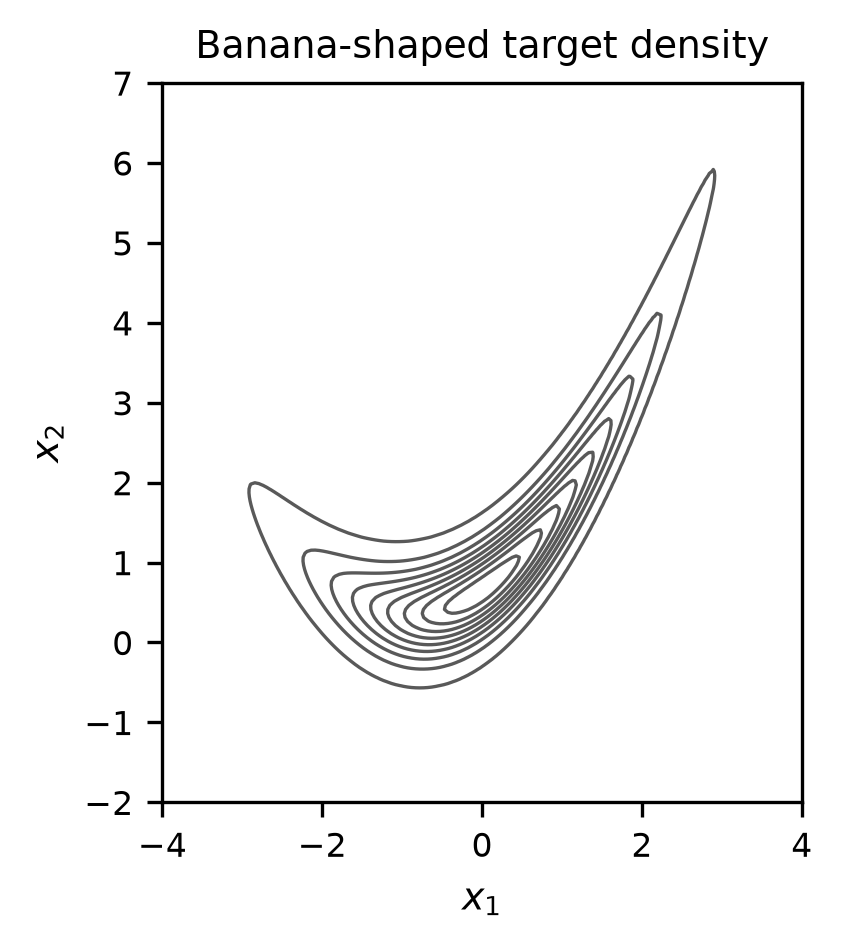

In [2]:
a = 1.15
b = 0.5
rho = 0.9
correlation = jnp.array([[1.0, rho], [rho, 1.0]])


def banana_logdensity(x):
    # Log density induced by the unit-Jacobian banana transformation.
    x1, x2 = x
    u1 = x1 / a
    u2 = a * (x2 - b * (u1**2 + a**2))
    u = jnp.array([u1, u2])
    return multivariate_normal.logpdf(u, jnp.zeros(2), correlation)


grid_x = jnp.linspace(-4.0, 4.0, 160)
grid_y = jnp.linspace(-2.0, 7.0, 180)
X_grid, Y_grid = jnp.meshgrid(grid_x, grid_y)
grid_points = jnp.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
target_density = jnp.exp(vmap(banana_logdensity)(grid_points)).reshape(X_grid.shape)


def draw_target_contours(ax):
    maximum = float(jnp.max(target_density))
    levels = np.linspace(0.04 * maximum, 0.92 * maximum, 9)
    ax.contour(
        np.asarray(X_grid),
        np.asarray(Y_grid),
        np.asarray(target_density),
        levels=levels,
        colors="0.35",
        linewidths=0.8,
    )
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-2.0, 7.0)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    finish_axes(ax, boxed=True)
    return ax


fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"], constrained_layout=True)
draw_target_contours(ax)
ax.set_title("Banana-shaped target density");


## Dynamic trajectories

NUTS grows a binary tree by extending a leapfrog trajectory in randomly chosen forward or backward directions. A valid progressive sampling rule selects the proposal from the constructed trajectory; a stopping test cannot simply be attached to ordinary HMC as a state-dependent path length. The original algorithm used recursive tree construction and slice-based selection. The pinned BlackJAX implementation uses iterative expansion and multinomial progressive selection together with a generalized U-turn test {cite:p}`hoffman2014nuts,betancourt2017conceptual,cabezas2024blackjax`.

BlackJAX uses an iterative generalized U-turn test. For a checked subtree $\mathcal{T}$, let $r^-$ and $r^+$ be the endpoint momenta and define the adjusted accumulated momentum

$$
\widetilde r_{\mathcal{T}}
=
\sum_{j\in\mathcal{T}} r_j-\frac{r^-+r^+}{2}.
$$

The subtree is turning when

$$
\left(M^{-1}r^-\right)^{\mathsf T}\widetilde r_{\mathcal{T}}\leq 0
\quad\text{or}\quad
\left(M^{-1}r^+\right)^{\mathsf T}\widetilde r_{\mathcal{T}}\leq 0.
$$

This discrete check is the implementation-level counterpart of the endpoint criterion introduced in the MCMC foundations section. BlackJAX also checks completed subtrees and stops after at most `max_num_doublings` tree expansions. We use ten expansions, which caps a transition at $2^{10}-1=1{,}023$ integration steps.


In [3]:
max_num_doublings = 10
divergence_threshold = 1_000.0
nuts_kernel = blackjax.nuts.build_kernel(
    divergence_threshold=divergence_threshold
)


def run_nuts_chain(
    key,
    initial_state,
    step_size,
    inverse_mass_matrix,
    num_draws,
):
    def one_step(carry, _):
        key, state = carry
        key, transition_key = jrandom.split(key)
        next_state, info = nuts_kernel(
            transition_key,
            state,
            banana_logdensity,
            step_size,
            inverse_mass_matrix,
            max_num_doublings=max_num_doublings,
        )
        initial_energy = -state.logdensity + 0.5 * jnp.sum(
            inverse_mass_matrix * info.momentum**2
        )
        output = (
            next_state.position,
            info.acceptance_rate,
            info.is_divergent,
            info.num_trajectory_expansions,
            info.num_integration_steps,
            initial_energy,
        )
        return (key, next_state), output

    (_, final_state), output = lax.scan(
        one_step,
        (key, initial_state),
        None,
        length=num_draws,
    )
    return final_state, output


## Window adaptation and inference

NUTS replaces the fixed integration-step count $L$ with dynamic path termination. Practical use still requires choices of mass-matrix class, target acceptance probability, warmup length, and maximum tree depth. We use BlackJAX window adaptation to estimate a diagonal inverse mass matrix and a step size separately for each chain. Dual averaging targets a mean acceptance probability $\delta=0.99$ {cite:p}`hoffman2014nuts,cabezas2024blackjax`. This deliberately conservative target is specified before inference and favors smaller step sizes on the curved density.

The four chains start from the same dispersed positions as the preceding experiments. Each chain performs $1{,}000$ adaptive warmup transitions. Its adapted step size and inverse mass matrix are then frozen, and every one of the following $5{,}000$ states is retained for inference. Warmup draws are excluded from all posterior summaries.


In [4]:
initial_positions = jnp.array(
    [
        [-4.0, 1.0],
        [-1.0, -1.0],
        [1.0, 4.0],
        [4.0, 6.0],
    ]
)

num_chains = initial_positions.shape[0]
num_warmup = 1_000
num_draws = 5_000
target_acceptance_rate = 0.99

warmup = blackjax.window_adaptation(
    blackjax.nuts,
    banana_logdensity,
    is_mass_matrix_diagonal=True,
    target_acceptance_rate=target_acceptance_rate,
    max_num_doublings=max_num_doublings,
)


def run_warmup(key, initial_position):
    return warmup.run(key, initial_position, num_warmup)


master_key = jrandom.PRNGKey(20260920)
warmup_key, inference_key = jrandom.split(master_key)
warmup_keys = jrandom.split(warmup_key, num_chains)
adaptation_results, warmup_info = jax.jit(vmap(run_warmup))(
    warmup_keys,
    initial_positions,
)

adapted_step_size = adaptation_results.parameters["step_size"]
adapted_inverse_mass_matrix = adaptation_results.parameters[
    "inverse_mass_matrix"
]

inference_keys = jrandom.split(inference_key, num_chains)
_, inference_output = jax.jit(
    vmap(run_nuts_chain, in_axes=(0, 0, 0, 0, None)),
    static_argnums=(4,),
)(
    inference_keys,
    adaptation_results.state,
    adapted_step_size,
    adapted_inverse_mass_matrix,
    num_draws,
)

(
    samples,
    inference_acceptance_probability,
    inference_is_divergent,
    inference_num_expansions,
    inference_num_steps,
    inference_initial_energy,
) = inference_output
samples.block_until_ready()

adaptation_rows = []
for chain in range(num_chains):
    adaptation_rows.append(
        [
            str(chain + 1),
            f"{float(adapted_step_size[chain]):.4f}",
            f"{float(adapted_inverse_mass_matrix[chain, 0]):.4f}",
            f"{float(adapted_inverse_mass_matrix[chain, 1]):.4f}",
        ]
    )

adaptation_latex_rows = [" & ".join(row) + r" \\" for row in adaptation_rows]
adaptation_latex = r'''
\begin{tabular}{lrrr}
\hline
Chain & Step size & $(M^{-1})_{11}$ & $(M^{-1})_{22}$ \\
\hline
''' + "\n".join(adaptation_latex_rows) + r'''
\hline
\end{tabular}
'''
math_class = 'class="math notranslate nohighlight"'
display_book_table(
    ["Chain", "Step size", "inv. mass x1", "inv. mass x2"],
    adaptation_rows,
    adaptation_latex,
    html_headers=[
        "Chain",
        "Step size",
        f"<span {math_class}>\\((M^{{-1}})_{{11}}\\)</span>",
        f"<span {math_class}>\\((M^{{-1}})_{{22}}\\)</span>",
    ],
)


Chain,Step size,\((M^{-1})_{11}\),\((M^{-1})_{22}\)
1,0.1108,1.0265,0.7304
2,0.1114,1.1605,0.9700
3,0.1264,1.0171,0.6753
4,0.0874,1.2759,0.8612


The trace display includes the complete warmup and the first $1{,}200$ inference draws. The vertical line marks the point at which adaptation ends and the transition parameters become fixed. Numerical summaries use all $20{,}000$ post-warmup states.


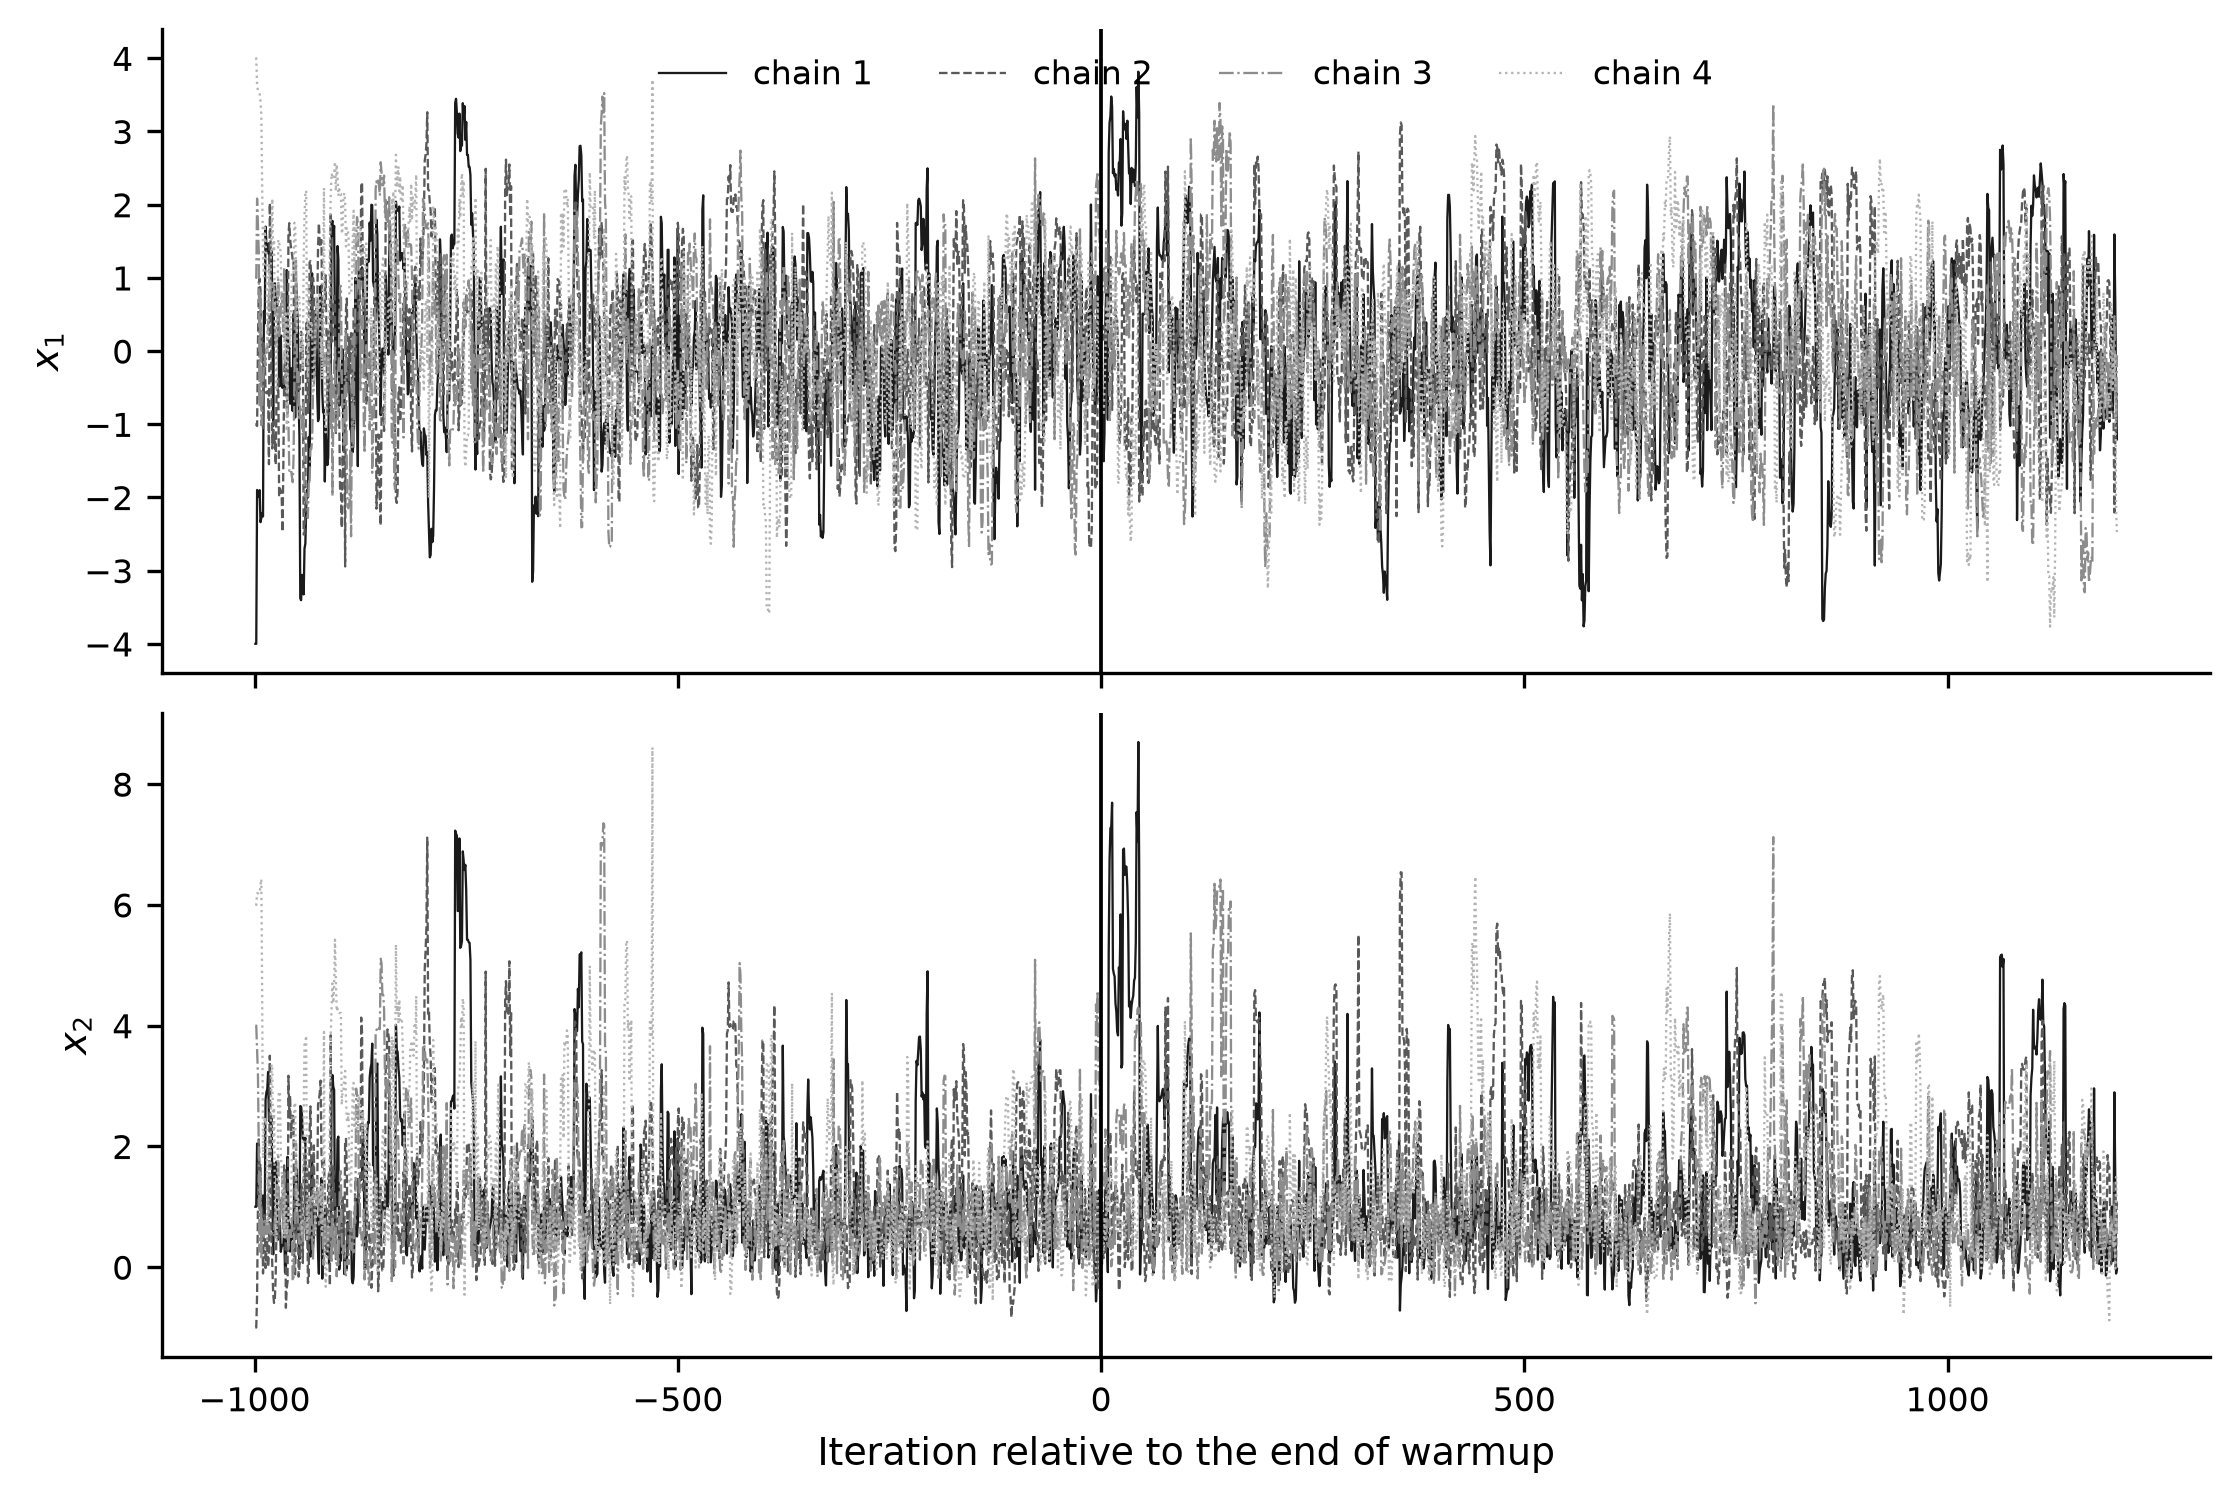

In [5]:
warmup_samples = np.asarray(warmup_info.state.position)
trace_draws = 1_200
trace_values = np.concatenate(
    [warmup_samples, np.asarray(samples[:, :trace_draws])],
    axis=1,
)
trace_iteration = np.arange(-num_warmup + 1, trace_draws + 1)

fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)
for chain in range(num_chains):
    color, linestyle = CHAIN_STYLES[chain]
    for coordinate, ax in enumerate(axes):
        ax.plot(
            trace_iteration,
            trace_values[chain, :, coordinate],
            color=color,
            linestyle=linestyle,
            linewidth=0.55,
            rasterized=True,
            label=f"chain {chain + 1}" if coordinate == 0 else None,
        )

for coordinate, ax in enumerate(axes):
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_ylabel(fr"$x_{coordinate + 1}$")
axes[0].legend(ncol=4, loc="upper center")
axes[-1].set_xlabel("Iteration relative to the end of warmup")
finish_axes(axes);


## Multiple-chain and NUTS diagnostics

We compute rank-normalized split and folded $\widehat R$, together with bulk and tail effective sample sizes, from the complete post-warmup arrays {cite:p}`vehtari2021rank`. The NUTS transition information supplies the mean acceptance probability across each constructed trajectory, divergent-transition flags, the number of tree expansions, and the number of integration steps.

A transition reaches the configured depth cap when `num_trajectory_expansions` equals ten. Depth-cap events primarily warn about efficiency; divergences can signal unreliable numerical trajectories. We also compute E-BFMI from the initial Hamiltonian after each momentum refresh, using the definition in the fixed-path HMC notebook {cite:p}`betancourt2017conceptual`. These checks diagnose different failure modes, and none establishes convergence by itself.


In [6]:
rhat = np.asarray(blackjax.rhat(samples))
bulk_ess = np.asarray(blackjax.ess_bulk(samples))
tail_ess = np.asarray(blackjax.ess_tail(samples))

diagnostic_rows = [
    ["Rank-normalized split/folded R-hat", f"{rhat[0]:.4f}", f"{rhat[1]:.4f}"],
    ["Bulk ESS", f"{bulk_ess[0]:.0f}", f"{bulk_ess[1]:.0f}"],
    ["Tail ESS", f"{tail_ess[0]:.0f}", f"{tail_ess[1]:.0f}"],
]
diagnostic_latex = rf'''
\begin{{tabular}}{{lrr}}
\hline
Quantity & $x_1$ & $x_2$ \\
\hline
Rank-normalized split/folded $\widehat R$ & {rhat[0]:.4f} & {rhat[1]:.4f} \\
Bulk ESS & {bulk_ess[0]:.0f} & {bulk_ess[1]:.0f} \\
Tail ESS & {tail_ess[0]:.0f} & {tail_ess[1]:.0f} \\
\hline
\end{{tabular}}
'''
diagnostic_html_rows = [
    [
        f"Rank-normalized split/folded <span {math_class}>\\(\\widehat R\\)</span>",
        diagnostic_rows[0][1],
        diagnostic_rows[0][2],
    ],
    diagnostic_rows[1],
    diagnostic_rows[2],
]
display_book_table(
    ["Quantity", "x1", "x2"],
    diagnostic_rows,
    diagnostic_latex,
    html_headers=[
        "Quantity",
        f"<span {math_class}>\\(x_1\\)</span>",
        f"<span {math_class}>\\(x_2\\)</span>",
    ],
    html_rows=diagnostic_html_rows,
)

acceptance_probability = np.asarray(inference_acceptance_probability)
divergences = np.asarray(inference_is_divergent)
num_expansions = np.asarray(inference_num_expansions)
num_steps = np.asarray(inference_num_steps)
energy_values = np.asarray(inference_initial_energy)

mean_acceptance_probability = acceptance_probability.mean(axis=1)
divergence_count = divergences.sum(axis=1)
depth_cap_count = (num_expansions == max_num_doublings).sum(axis=1)
mean_num_steps = num_steps.mean(axis=1)
percentile_90_num_steps = np.percentile(num_steps, 90, axis=1)
e_bfmi = np.mean(np.diff(energy_values, axis=1) ** 2, axis=1) / np.var(
    energy_values,
    axis=1,
)

nuts_rows = []
for chain in range(num_chains):
    nuts_rows.append(
        [
            str(chain + 1),
            f"{mean_acceptance_probability[chain]:.3f}",
            str(int(divergence_count[chain])),
            str(int(depth_cap_count[chain])),
            f"{mean_num_steps[chain]:.1f}",
            f"{percentile_90_num_steps[chain]:.0f}",
            f"{e_bfmi[chain]:.3f}",
        ]
    )

nuts_latex_rows = [" & ".join(row) + r" \\" for row in nuts_rows]
nuts_latex = r'''
\begin{tabular}{lrrrrrr}
\hline
Chain & Mean accept. & Div. & Depth cap & Mean steps & 90\% steps & E-BFMI \\
\hline
''' + "\n".join(nuts_latex_rows) + r'''
\hline
\end{tabular}
'''
display_book_table(
    [
        "Chain",
        "Mean accept.",
        "Div.",
        "Depth cap",
        "Mean steps",
        "90% steps",
        "E-BFMI",
    ],
    nuts_rows,
    nuts_latex,
)


Quantity,\(x_1\),\(x_2\)
Rank-normalized split/folded \(\widehat R\),1.0020,1.0012
Bulk ESS,1882,2713
Tail ESS,2274,2199


Chain,Mean accept.,Div.,Depth cap,Mean steps,90% steps,E-BFMI
1,0.988,0,0,17.5,31,0.949
2,0.986,0,0,16.3,31,0.992
3,0.985,0,0,16.3,31,0.989
4,0.991,0,0,20.4,39,1.034


Pooled-rank histograms complement the numerical summaries. Chains exploring the same distribution should contribute comparably throughout the pooled ranks; exact uniformity is neither expected nor required.


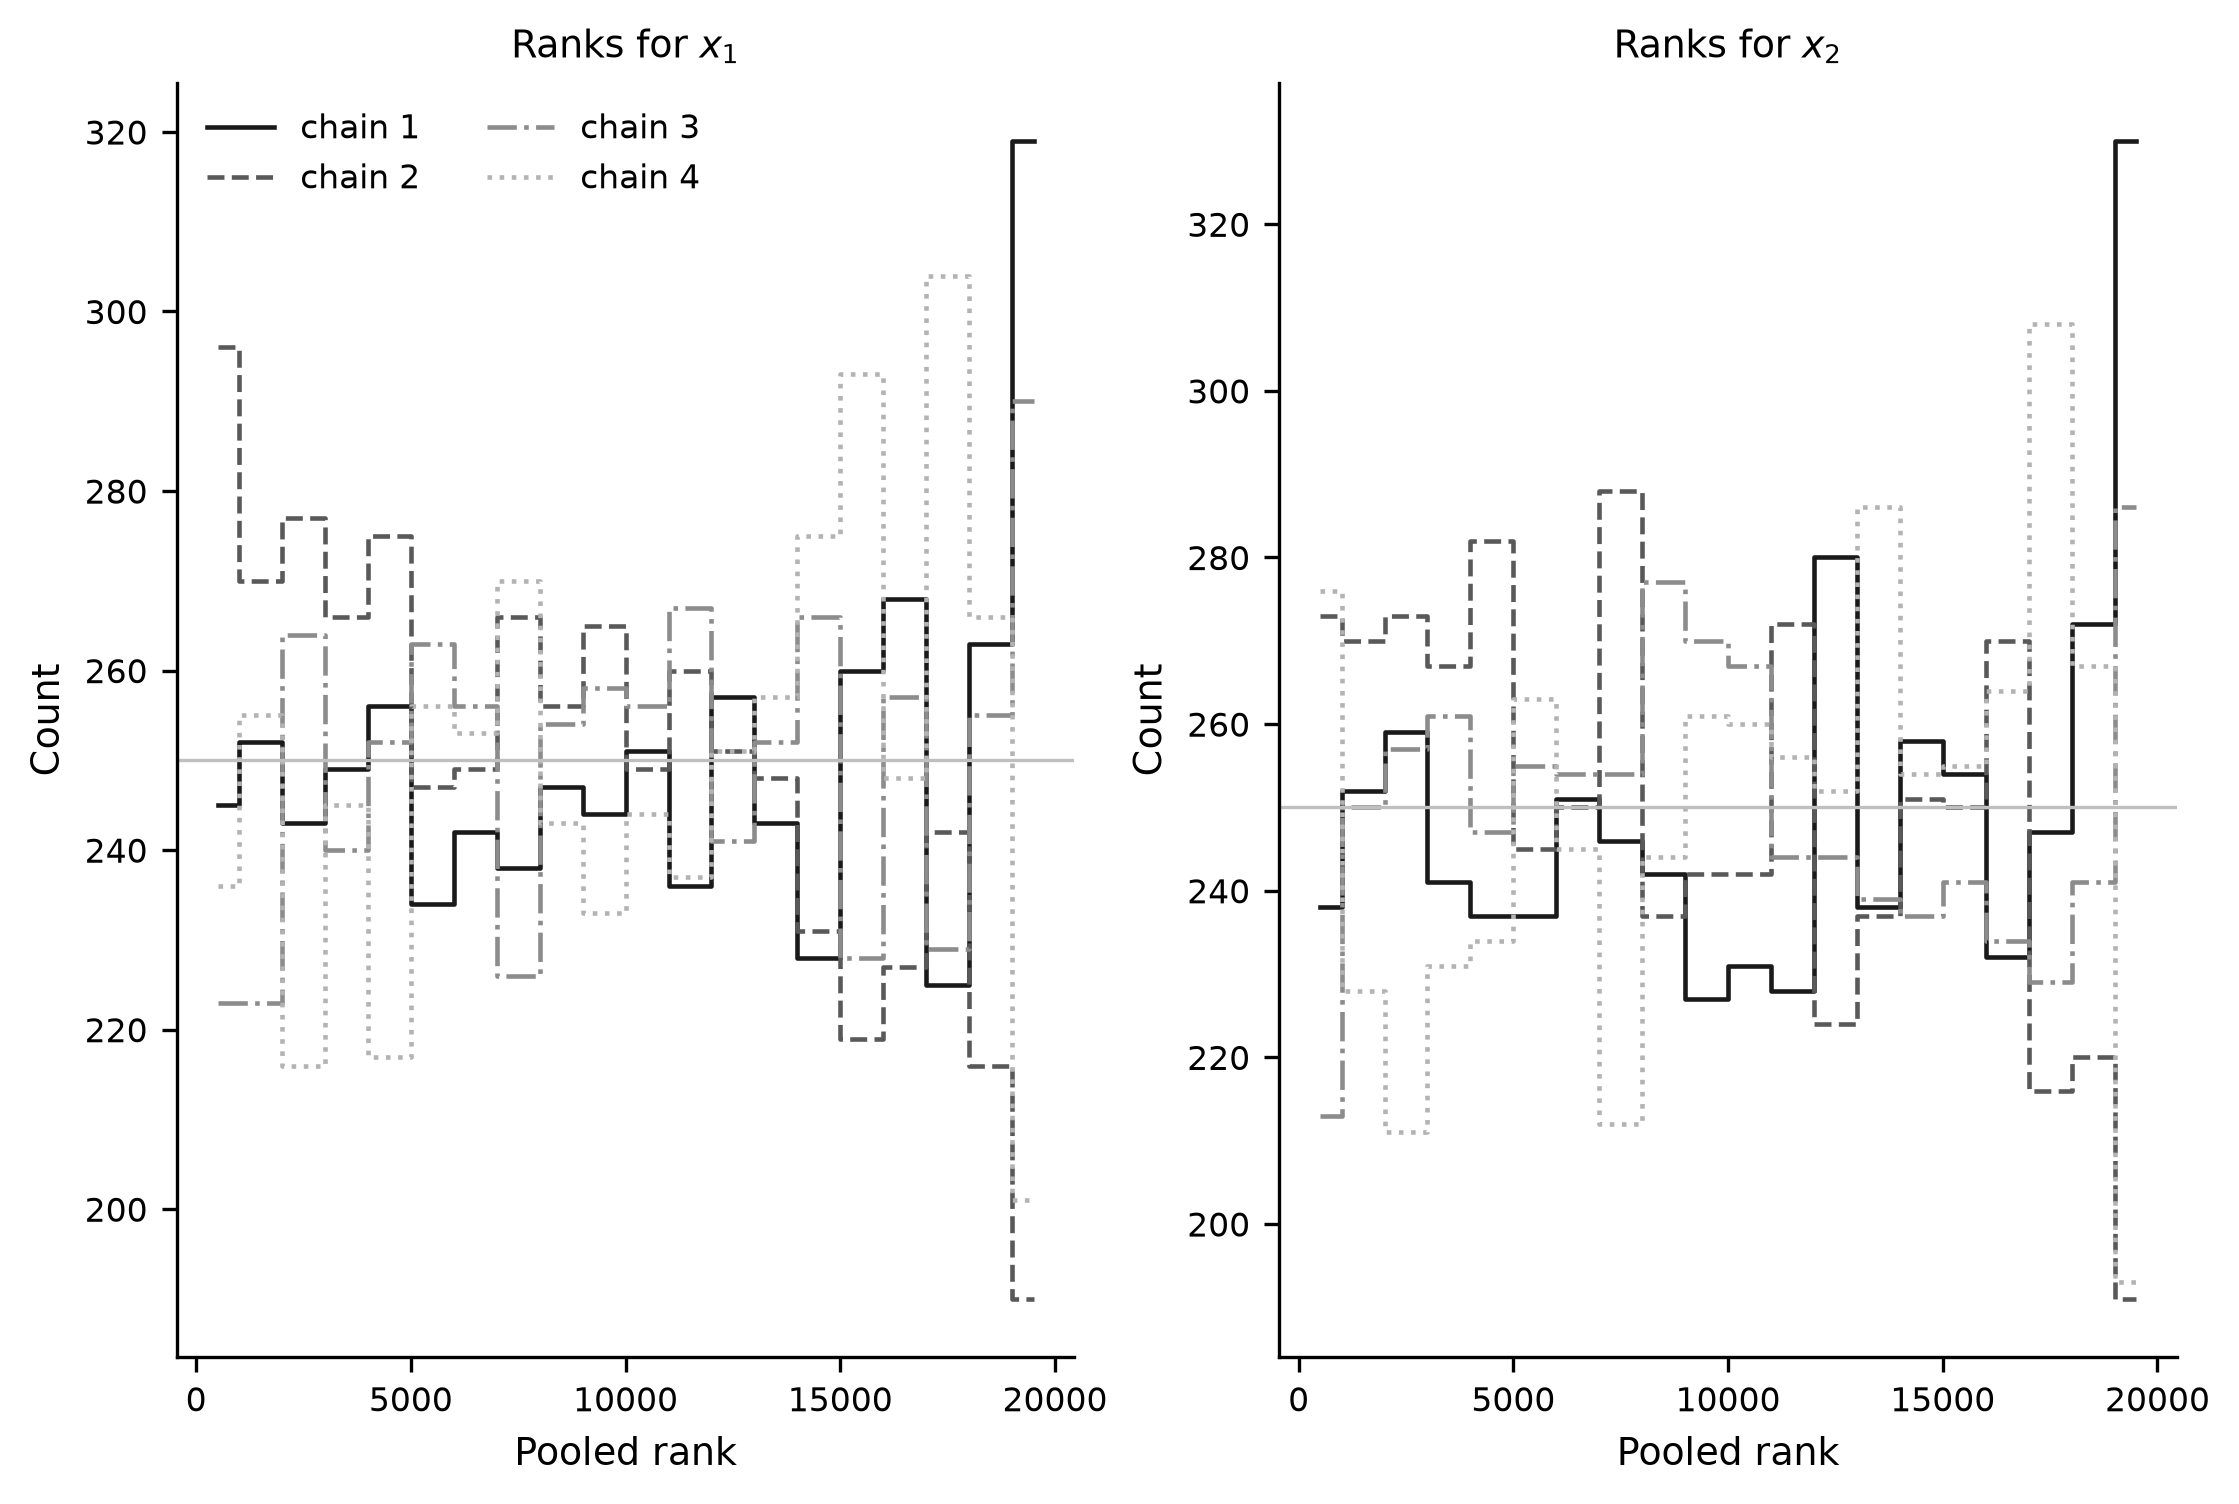

In [7]:
num_rank_bins = 20
fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)

for coordinate, ax in enumerate(axes):
    pooled = np.asarray(samples[:, :, coordinate])
    ranks = rankdata(pooled.ravel(), method="average").reshape(pooled.shape)
    bin_edges = np.linspace(0.5, ranks.size + 0.5, num_rank_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    for chain in range(num_chains):
        color, linestyle = CHAIN_STYLES[chain]
        counts, _ = np.histogram(ranks[chain], bins=bin_edges)
        ax.step(
            bin_centers,
            counts,
            where="mid",
            color=color,
            linestyle=linestyle,
            label=f"chain {chain + 1}",
        )
    ax.axhline(num_draws / num_rank_bins, color="0.75", linewidth=0.8)
    ax.set_title(fr"Ranks for $x_{coordinate + 1}$")
    ax.set_xlabel("Pooled rank")
    ax.set_ylabel("Count")

axes[0].legend(ncol=2)
finish_axes(axes);


## Variable computational work

NUTS replaces the fixed HMC path length with variable work at each transition. The integration-step count is therefore both an algorithm diagnostic and a first approximation to gradient cost. The empirical distribution below uses every inference transition. It is not an efficiency comparison with the preceding HMC run because the runs contain different numbers of retained states and omit a common wall-time protocol.


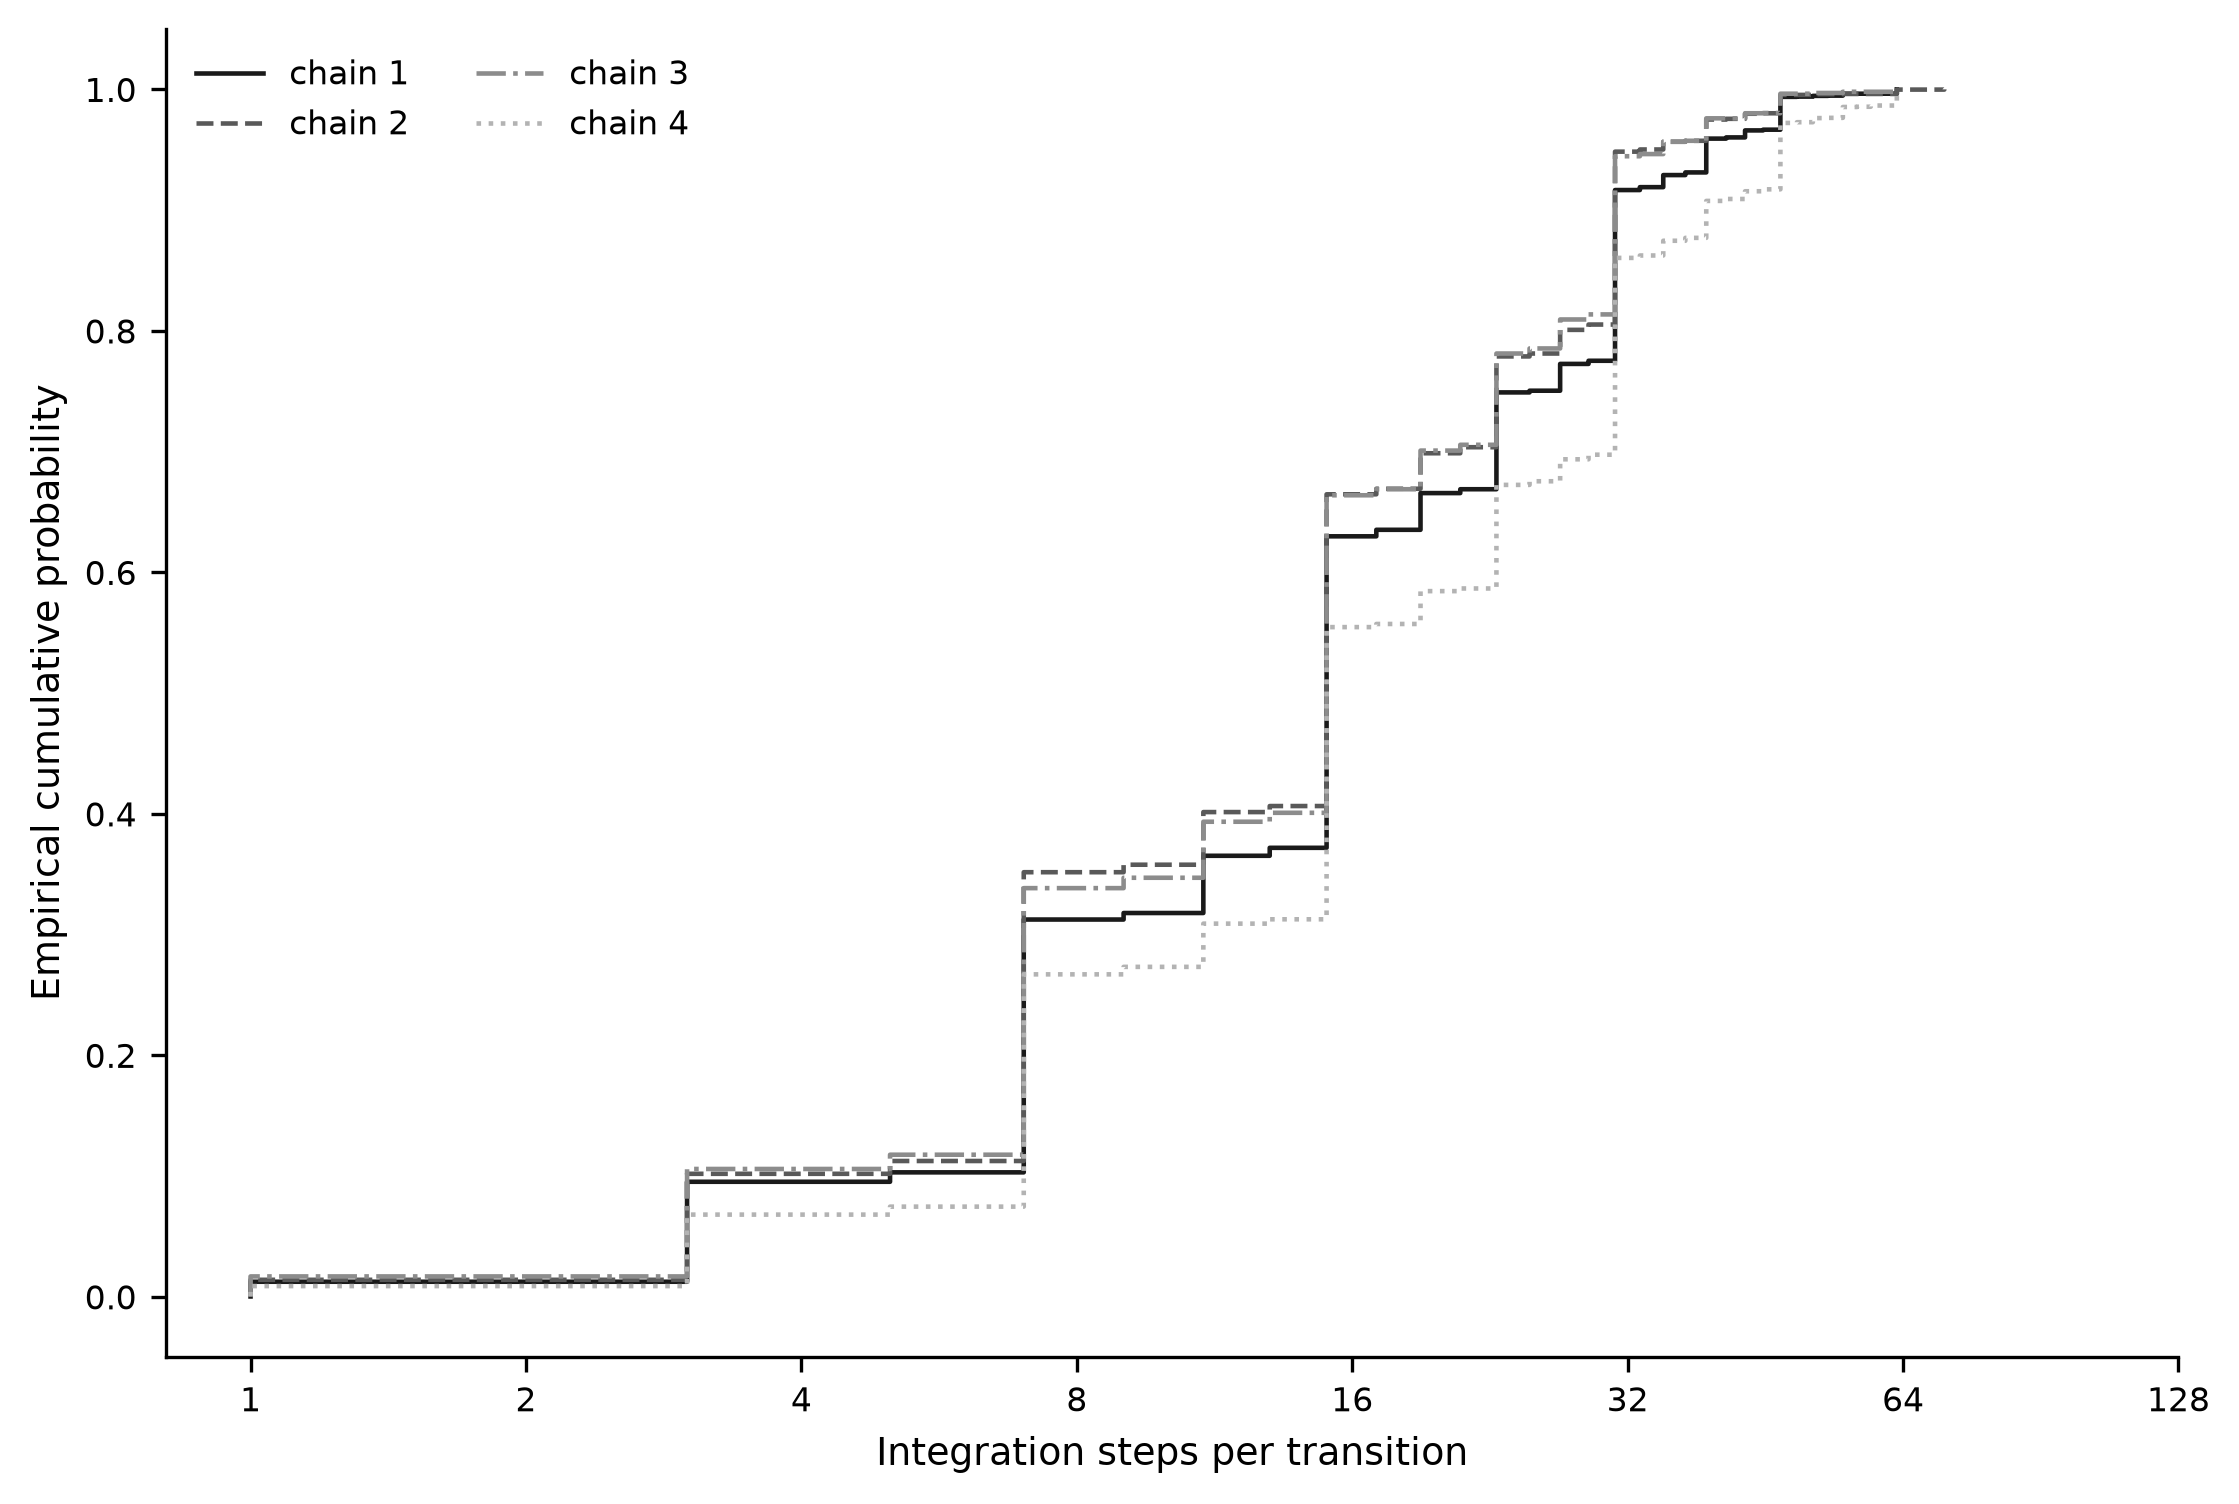

In [8]:
fig, ax = plt.subplots(
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)
for chain in range(num_chains):
    color, linestyle = CHAIN_STYLES[chain]
    ordered_steps = np.sort(num_steps[chain])
    probability = np.arange(1, num_draws + 1) / num_draws
    ax.step(
        ordered_steps,
        probability,
        where="post",
        color=color,
        linestyle=linestyle,
        label=f"chain {chain + 1}",
    )

ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Integration steps per transition")
ax.set_ylabel("Empirical cumulative probability")
ax.legend(ncol=2)
finish_axes(ax);


## Monte Carlo precision and an exact check

The transformation gives

$$
\begin{aligned}
\mathbb{E}[X_1]&=0,
&\mathbb{E}[X_2]&=b(1+a^2),\\
\mathbb{E}[X_1^2]&=a^2,
&\mathbb{E}[X_1X_2]&=\rho,\\
\operatorname{Var}(X_2)&=a^{-2}+2b^2.
\end{aligned}
$$

Consequently,

$$
\mathbb{E}[X_2^2]
=
a^{-2}+2b^2+b^2(1+a^2)^2.
$$

For each scalar estimand $g(X)$, we report

$$
\operatorname{MCSE}(\bar g)
\approx
\sqrt{\frac{\widehat{\operatorname{Var}}(g(X))}{N_{\mathrm{eff},g}}}.
$$

Here $\bar g$ averages all retained chains and draws, and $N_{\mathrm{eff},g}$ is the estimand-specific effective sample size.


In [9]:
moment_draws = jnp.stack(
    [
        samples[..., 0],
        samples[..., 1],
        samples[..., 0] ** 2,
        samples[..., 0] * samples[..., 1],
        samples[..., 1] ** 2,
    ],
    axis=-1,
)

exact_moments = np.array(
    [
        0.0,
        b * (1.0 + a**2),
        a**2,
        rho,
        a ** (-2) + 2.0 * b**2 + b**2 * (1.0 + a**2) ** 2,
    ]
)
moment_names = [
    "E[X1]",
    "E[X2]",
    "E[X1^2]",
    "E[X1 X2]",
    "E[X2^2]",
]
moment_names_latex = [
    r"$\mathbb{E}[X_1]$",
    r"$\mathbb{E}[X_2]$",
    r"$\mathbb{E}[X_1^2]$",
    r"$\mathbb{E}[X_1X_2]$",
    r"$\mathbb{E}[X_2^2]$",
]
moment_names_html = [
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1^2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2^2]\\)</span>",
]

moment_estimates = np.asarray(moment_draws.mean(axis=(0, 1)))
moment_ess = np.asarray(blackjax.ess(moment_draws))
moment_rhat = np.asarray(blackjax.rhat(moment_draws))
moment_variances = np.asarray(moment_draws).reshape(-1, len(moment_names)).var(
    axis=0,
    ddof=1,
)
moment_mcse = np.sqrt(moment_variances / moment_ess)

moment_rows = []
for name, exact, estimate, mcse, value_rhat, value_ess in zip(
    moment_names,
    exact_moments,
    moment_estimates,
    moment_mcse,
    moment_rhat,
    moment_ess,
):
    moment_rows.append(
        [
            name,
            f"{exact:.4f}",
            f"{estimate:.4f}",
            f"{mcse:.4f}",
            f"{value_rhat:.4f}",
            f"{value_ess:.0f}",
        ]
    )

moment_latex_rows = []
for name, row in zip(moment_names_latex, moment_rows):
    moment_latex_rows.append(name + " & " + " & ".join(row[1:]) + r" \\")
moment_latex = r'''
\begin{tabular}{lrrrrr}
\hline
Estimand & Exact & Estimate & MCSE & $\widehat R$ & ESS for $\bar g$ \\
\hline
''' + "\n".join(moment_latex_rows) + r'''
\hline
\end{tabular}
'''
moment_html_rows = [
    [html_name] + row[1:]
    for html_name, row in zip(moment_names_html, moment_rows)
]
display_book_table(
    ["Estimand", "Exact", "Estimate", "MCSE", "R-hat", "ESS for mean"],
    moment_rows,
    moment_latex,
    html_headers=[
        "Estimand",
        "Exact",
        "Estimate",
        "MCSE",
        f"<span {math_class}>\\(\\widehat R\\)</span>",
        f"ESS for <span {math_class}>\\(\\bar g\\)</span>",
    ],
    html_rows=moment_html_rows,
)


Estimand,Exact,Estimate,MCSE,\(\widehat R\),ESS for \(\bar g\)
\(\mathbb{E}[X_1]\),0.0000,0.0396,0.0270,1.0020,1860
\(\mathbb{E}[X_2]\),1.1612,1.1970,0.0271,1.0012,1871
\(\mathbb{E}[X_1^2]\),1.3225,1.3573,0.0399,1.0007,2300
\(\mathbb{E}[X_1X_2]\),0.9000,1.0243,0.0851,1.0018,1498
\(\mathbb{E}[X_2^2]\),2.6046,2.8088,0.1512,1.0012,1580


Every inference state remains in the diagnostic and moment calculations. Effective sample size measures the precision loss or gain induced by serial dependence; it does not prescribe a thinning interval. Routine thinning would discard information unless storage or downstream processing is the limiting cost {cite:p}`link2012thinning`.

The final figure displays every fifth state to control overplotting. This is display subsampling only; the numerical results use the complete inference array.


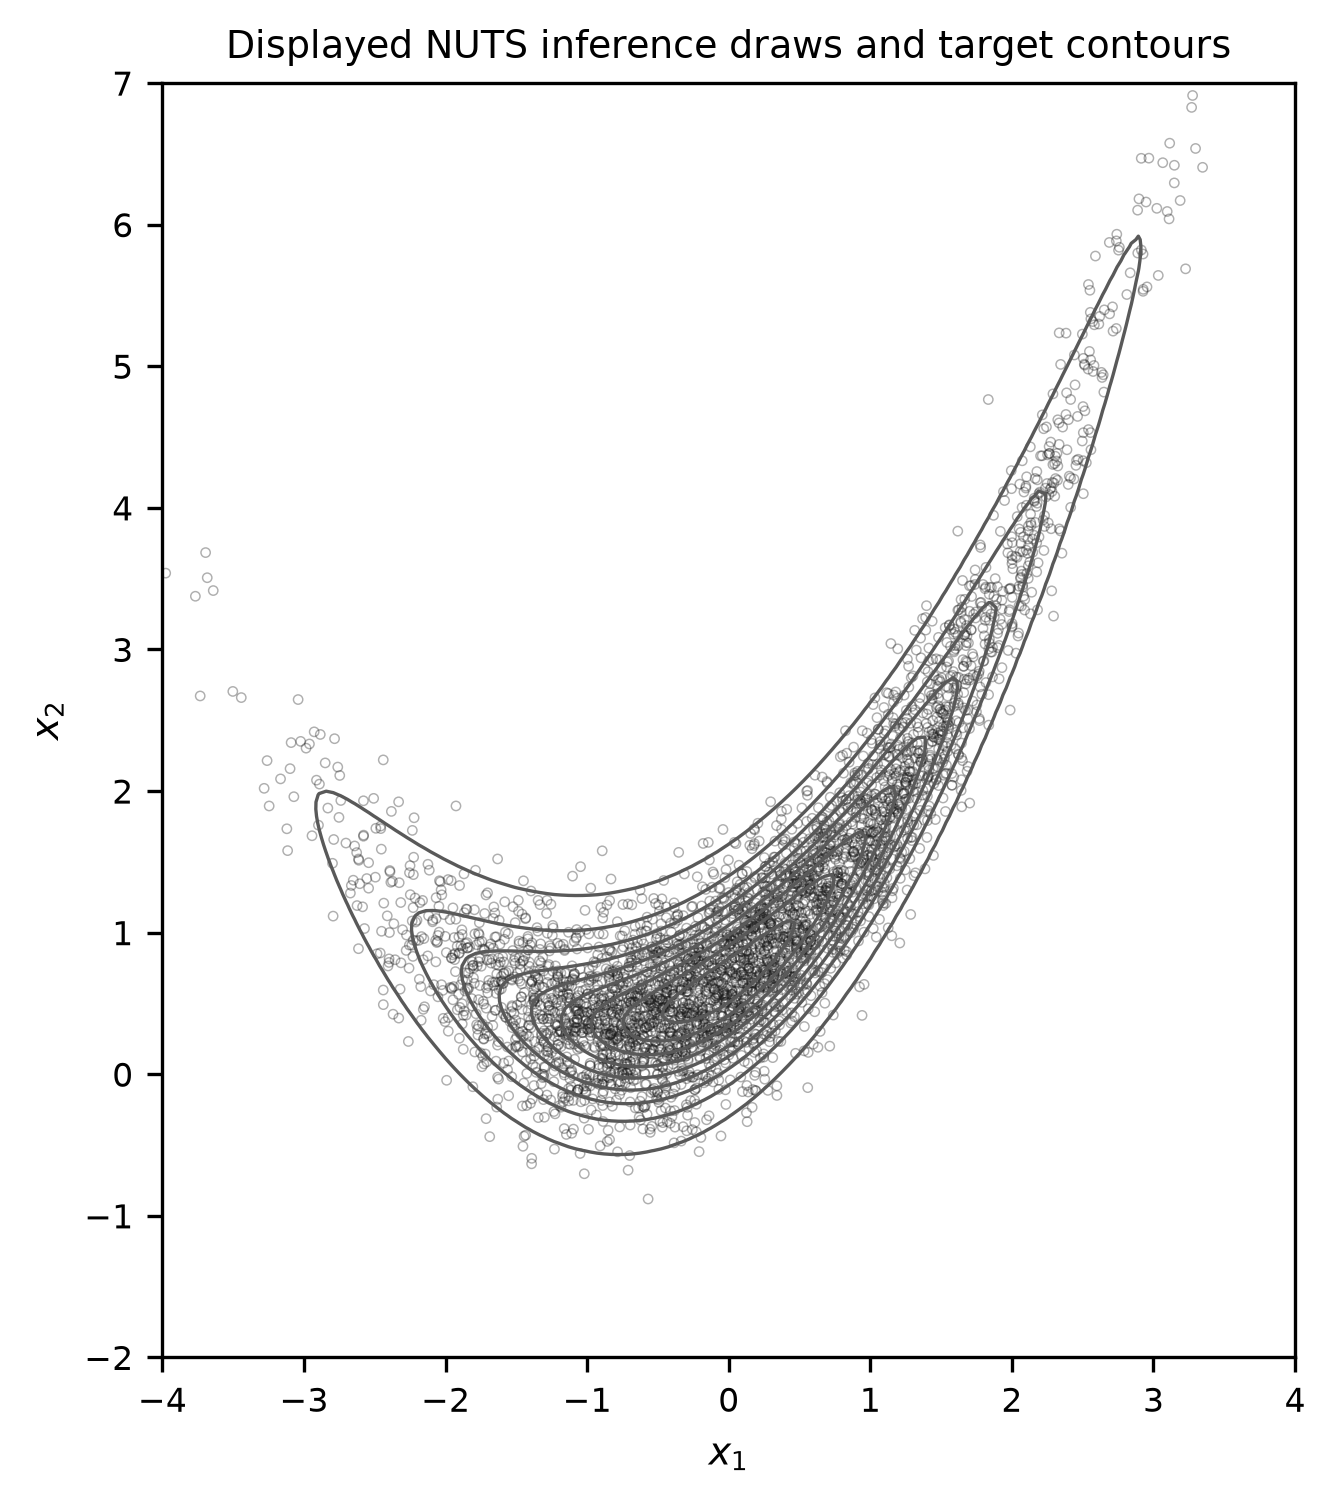

In [10]:
display_stride = 5
display_samples = np.asarray(samples[:, ::display_stride]).reshape(-1, 2)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"], constrained_layout=True)
draw_target_contours(ax)
ax.scatter(
    display_samples[:, 0],
    display_samples[:, 1],
    s=5,
    facecolors="none",
    edgecolors="0.10",
    linewidths=0.35,
    alpha=0.35,
    rasterized=True,
)
ax.set_title("Displayed NUTS inference draws and target contours");


## Diagnostic interpretation

For this stored run, the coordinate and moment $\widehat R$ values satisfy the $1.01$ warning screen, the rank plots show no clear chain separation, no post-warmup transition is divergent, no transition reaches the maximum tree depth, and the E-BFMI values reveal no evident energy-exploration warning. The exact moments agree with the estimates at the scale indicated by their MCSEs. These results reveal no detected failure; they do not prove convergence.

The conservative target acceptance probability produces high acceptance probabilities and variable trajectories that typically require more than the ten integration steps used by the preceding fixed-path HMC run. Compare the algorithms using ESS per gradient evaluation or per second, or compare MCSE at a matched gradient-evaluation or wall-time budget. ESS per retained state alone is not a computational-efficiency comparison.

NUTS completes the progression from random-walk Metropolis to fixed-path HMC and then to dynamic Hamiltonian trajectories. The next chapter changes the computational strategy: variational inference replaces sampling from the target with optimization over a tractable family of approximate distributions.

## Exercises

1. In a warmup-only pilot, compare target acceptance probabilities $0.8$, $0.9$, and $0.99$. Freeze the selected setting before generating fresh inference draws, then compare divergences, integration-step counts, and MCSE.
2. Replace diagonal mass-matrix adaptation with dense adaptation. Compare the adapted matrices and cost-normalized precision.
3. Reduce `max_num_doublings` from ten to six. Count depth-cap events and explain why the cap is primarily an efficiency diagnostic.
4. Compare fixed-path HMC and NUTS using ESS per integration step and ESS per unit wall time. Alternatively, compare MCSE at matched integration-step and wall-time budgets. Separate compilation time from sampling time.
5. Recreate the final scatter plot with a different display stride and verify that the numerical summaries remain unchanged.
